In [ ]:
# dataset_generator.py
import json
import random
import datetime
import uuid
import threading
import numpy as np
from faker import Faker

fake = Faker()

# --- Configuration ---
NUM_USERS = 10000
NUM_PRODUCTS = 5000
NUM_CATEGORIES = 25
NUM_TRANSACTIONS = 500000
NUM_SESSIONS = 2000000
TIMESPAN_DAYS = 90
MAX_ITERATIONS = (NUM_SESSIONS + NUM_TRANSACTIONS) * 2  # Fail-safe

# --- Initialization ---
np.random.seed(42)
random.seed(42)
Faker.seed(42)

print("Initializing dataset generation...")

# --- ID Generators ---
def generate_session_id():
    return f"sess_{uuid.uuid4().hex[:10]}"

def generate_transaction_id():
    return f"txn_{uuid.uuid4().hex[:12]}"

# --- Inventory Management ---
class InventoryManager:
    def __init__(self, products):
        self.products = {p["product_id"]: p for p in products}
        self.lock = threading.RLock()  # For thread safety

    def update_stock(self, product_id, quantity):
        with self.lock:
            if product_id not in self.products:
                return False
            if self.products[product_id]["current_stock"] >= quantity:
                self.products[product_id]["current_stock"] -= quantity
                return True
            return False

    def get_product(self, product_id):
        with self.lock:
            return self.products.get(product_id)

# --- Helper Functions ---
def determine_page_type(position, previous_pages):
    """
    Determine page type based on position in user journey and previous pages viewed.
    """
    if position == 0:
        # First page is usually homepage, search or category
        return random.choice(["home", "search", "category_listing"])

    if not previous_pages:
        return "home"

    prev_page = previous_pages[-1]["page_type"]

    # Define realistic page flow transitions
    if prev_page == "home":
        return random.choices(
            ["category_listing", "search", "product_detail"],
            weights=[0.5, 0.3, 0.2]
        )[0]
    elif prev_page == "category_listing":
        return random.choices(
            ["product_detail", "category_listing", "search", "home"],
            weights=[0.7, 0.1, 0.1, 0.1]
        )[0]
    elif prev_page == "search":
        return random.choices(
            ["product_detail", "search", "category_listing", "home"],
            weights=[0.6, 0.2, 0.1, 0.1]
        )[0]
    elif prev_page == "product_detail":
        return random.choices(
            ["product_detail", "cart", "category_listing", "search", "home"],
            weights=[0.3, 0.3, 0.2, 0.1, 0.1]
        )[0]
    elif prev_page == "cart":
        return random.choices(
            ["checkout", "product_detail", "category_listing", "home"],
            weights=[0.6, 0.2, 0.1, 0.1]
        )[0]
    elif prev_page == "checkout":
        return random.choices(
            ["confirmation", "cart", "home"],
            weights=[0.8, 0.1, 0.1]
        )[0]
    elif prev_page == "confirmation":
        return random.choices(
            ["home", "product_detail", "category_listing"],
            weights=[0.6, 0.2, 0.2]
        )[0]
    else:
        return "home"

def get_page_content(page_type, products_list, categories_list, inventory):
    """
    Get appropriate product and category based on page type.
    Returns active products and categories with stock.
    """
    if page_type == "product_detail":
        # Try to find an active product with stock
        attempts = 0
        while attempts < 10:  # Limit attempts to avoid infinite loop
            product = random.choice(products_list)
            if product["is_active"] and product["current_stock"] > 0:
                category_id = product["category_id"]
                category = next((c for c in categories_list if c["category_id"] == category_id), None)
                return product, category
            attempts += 1

        # If we couldn't find a suitable product after attempts, just return any
        product = random.choice(products_list)
        category_id = product["category_id"]
        category = next((c for c in categories_list if c["category_id"] == category_id), None)
        return product, category

    elif page_type == "category_listing":
        category = random.choice(categories_list)
        return None, category

    else:
        return None, None

# --- Category Generation ---
categories = []
for cat_id in range(NUM_CATEGORIES):
    category = {
        "category_id": f"cat_{cat_id:03d}",
        "name": fake.company(),
        "subcategories": []
    }

    for sub_id in range(random.randint(3, 5)):
        subcategory = {
            "subcategory_id": f"sub_{cat_id:03d}_{sub_id:02d}",
            "name": fake.bs(),
            "profit_margin": round(random.uniform(0.1, 0.4), 2)
        }
        category["subcategories"].append(subcategory)

    categories.append(category)

print(f"Generated {len(categories)} categories")

# --- Product Generation ---
products = []
product_creation_start = datetime.datetime.now() - datetime.timedelta(days=TIMESPAN_DAYS*2)

for prod_id in range(NUM_PRODUCTS):
    category = random.choice(categories)

    # Generate price history with 1-3 price points
    base_price = round(random.uniform(5, 500), 2)
    price_history = []

    # Initial price
    initial_date = fake.date_time_between(
        start_date=product_creation_start,
        end_date=product_creation_start + datetime.timedelta(days=TIMESPAN_DAYS//3)
    )
    price_history.append({
        "price": base_price,
        "date": initial_date.isoformat()
    })

    # Add 0-2 more price changes
    for _ in range(random.randint(0, 2)):
        price_change_date = fake.date_time_between(
            start_date=initial_date,
            end_date="now"
        )
        new_price = round(base_price * random.uniform(0.8, 1.2), 2)  # +/- 20%
        price_history.append({
            "price": new_price,
            "date": price_change_date.isoformat()
        })
        initial_date = price_change_date

    # Sort price history by date
    price_history.sort(key=lambda x: x["date"])

    # Get current price (most recent in history)
    current_price = price_history[-1]["price"]

    products.append({
        "product_id": f"prod_{prod_id:05d}",
        "name": fake.catch_phrase().title(),
        "category_id": category["category_id"],
        "base_price": current_price,
        "current_stock": random.randint(10, 1000),  # Minimum stock
        "is_active": random.choices([True, False], weights=[0.95, 0.05])[0],
        "price_history": price_history,
        "creation_date": price_history[0]["date"]
    })

print(f"Generated {len(products)} products")

# --- User Generation ---
users = []
for user_id in range(NUM_USERS):
    reg_date = fake.date_time_between(
        start_date=f"-{TIMESPAN_DAYS*3}d",
        end_date=f"-{TIMESPAN_DAYS}d"
    )

    users.append({
        "user_id": f"user_{user_id:06d}",
        "geo_data": {
            "city": fake.city(),
            "state": fake.state_abbr(),
            "country": fake.country_code()
        },
        "registration_date": reg_date.isoformat(),
        "last_active": fake.date_time_between(start_date=reg_date, end_date="now").isoformat()
    })

print(f"Generated {len(users)} users")

# --- Session & Transaction Generation ---
inventory = InventoryManager(products)
sessions = []
transactions = []
transaction_counter = 0
session_counter = 0
iteration = 0

print("Generating sessions and transactions...")
while (session_counter < NUM_SESSIONS or transaction_counter < NUM_TRANSACTIONS) and iteration < MAX_ITERATIONS:
    iteration += 1

    # Session Generation
    if session_counter < NUM_SESSIONS:
        user = random.choice(users)
        session_id = generate_session_id()
        session_start = fake.date_time_between(
            start_date=f"-{TIMESPAN_DAYS}d",
            end_date="now"
        )
        session_duration = random.randint(30, 3600)  # 30 sec to 1 hour

        # Generate realistic page flow
        page_views = []
        viewed_products = set()
        cart_contents = {}

        # Generate page view timeline with proper time distribution
        time_slots = sorted([0] + [random.randint(1, session_duration-1) for _ in range(random.randint(3, 15))] + [session_duration])

        for i in range(len(time_slots)-1):
            view_duration = time_slots[i+1] - time_slots[i]
            page_type = determine_page_type(i, page_views)
            product, category = get_page_content(page_type, products, categories, inventory)

            # Track product views and cart interactions
            if page_type == "product_detail" and product:
                product_id = product["product_id"]
                viewed_products.add(product_id)

                # Only allow adding to cart for products that were viewed
                if random.random() < 0.3:
                    if product_id not in cart_contents:
                        cart_contents[product_id] = {
                            "quantity": 0,
                            "price": product["base_price"]
                        }

                    # Check current stock via inventory manager
                    max_possible = min(3, inventory.get_product(product_id)["current_stock"] - cart_contents[product_id]["quantity"])
                    if max_possible > 0:
                        add_qty = random.randint(1, max_possible)
                        cart_contents[product_id]["quantity"] += add_qty

            page_views.append({
                "timestamp": (session_start + datetime.timedelta(seconds=time_slots[i])).isoformat(),
                "page_type": page_type,
                "product_id": product["product_id"] if product else None,
                "category_id": category["category_id"] if category else None,
                "view_duration": view_duration
            })

        # Determine conversion - only if they have cart contents and viewed checkout or confirmation pages
        converted = False
        if cart_contents and any(p["page_type"] in ["checkout", "confirmation"] for p in page_views):
            converted = random.random() < 0.7  # 70% chance of completing checkout if reached checkout page

        # Geographic consistency - use user's geo plus random IP
        session_geo = user["geo_data"].copy()
        session_geo["ip_address"] = fake.ipv4()

        # Build session
        sessions.append({
            "session_id": session_id,
            "user_id": user["user_id"],
            "start_time": session_start.isoformat(),
            "end_time": (session_start + datetime.timedelta(seconds=session_duration)).isoformat(),
            "duration_seconds": session_duration,
            "geo_data": session_geo,
            "device_profile": {
                "type": random.choice(["mobile", "desktop", "tablet"]),
                "os": random.choice(["iOS", "Android", "Windows", "macOS"]),
                "browser": random.choice(["Chrome", "Safari", "Firefox", "Edge"])
            },
            "viewed_products": list(viewed_products),
            "page_views": page_views,
            "cart_contents": {k:v for k,v in cart_contents.items() if v["quantity"] > 0},
            "conversion_status": "converted" if converted else "abandoned" if cart_contents else "browsed",
            "referrer": random.choice(["direct", "email", "social", "search_engine", "affiliate"])
        })

        session_counter += 1

        # Create transaction if converted
        if converted and transaction_counter < NUM_TRANSACTIONS:
            transaction_items = []
            valid = True

            # Process each item in cart
            for prod_id, details in cart_contents.items():
                quantity = details["quantity"]
                if quantity > 0:
                    # Attempt to update inventory
                    if inventory.update_stock(prod_id, quantity):
                        transaction_items.append({
                            "product_id": prod_id,
                            "quantity": quantity,
                            "unit_price": details["price"],
                            "subtotal": round(quantity * details["price"], 2)
                        })
                    else:
                        # If any item's inventory update fails, mark transaction as invalid
                        valid = False
                        break

            if valid and transaction_items:
                # Calculate total with possible discount
                subtotal = sum(item["subtotal"] for item in transaction_items)
                discount = 0
                if random.random() < 0.2:  # 20% chance of discount
                    discount_rate = random.choice([0.05, 0.1, 0.15, 0.2])
                    discount = round(subtotal * discount_rate, 2)

                total = round(subtotal - discount, 2)

                transactions.append({
                    "transaction_id": generate_transaction_id(),
                    "session_id": session_id,  # Link to the session
                    "user_id": user["user_id"],
                    "timestamp": (session_start + datetime.timedelta(seconds=session_duration)).isoformat(),
                    "items": transaction_items,
                    "subtotal": subtotal,
                    "discount": discount,
                    "total": total,
                    "payment_method": random.choice(["credit_card", "paypal", "apple_pay", "crypto"]),
                    "status": "completed"
                })
                transaction_counter += 1

    # Generate additional transactions if needed
    if transaction_counter < NUM_TRANSACTIONS and random.random() < 0.2:
        user = random.choice(users)
        products_in_txn = random.sample(products, k=min(3, len(products)))

        transaction_items = []
        for product in products_in_txn:
            if product["is_active"]:
                quantity = random.randint(1, 3)
                if inventory.update_stock(product["product_id"], quantity):
                    transaction_items.append({
                        "product_id": product["product_id"],
                        "quantity": quantity,
                        "unit_price": product["base_price"],
                        "subtotal": round(quantity * product["base_price"], 2)
                    })

        if transaction_items:
            # Calculate total with possible discount
            subtotal = sum(item["subtotal"] for item in transaction_items)
            discount = 0
            if random.random() < 0.2:
                discount_rate = random.choice([0.05, 0.1, 0.15, 0.2])
                discount = round(subtotal * discount_rate, 2)

            total = round(subtotal - discount, 2)

            transactions.append({
                "transaction_id": generate_transaction_id(),
                "session_id": None,  # Not linked to a specific session
                "user_id": user["user_id"],
                "timestamp": fake.date_time_between(
                    start_date=f"-{TIMESPAN_DAYS}d",
                    end_date="now"
                ).isoformat(),
                "items": transaction_items,
                "subtotal": subtotal,
                "discount": discount,
                "total": total,
                "payment_method": random.choice(["credit_card", "paypal", "bank_transfer", "gift_card"]),
                "status": random.choice(["completed", "processing", "shipped", "delivered"])
            })
            transaction_counter += 1

    # Progress update
    if iteration % 10000 == 0:
        print(f"Progress: {session_counter:,}/{NUM_SESSIONS:,} sessions, {transaction_counter:,}/{NUM_TRANSACTIONS:,} transactions (iteration {iteration:,})")

# --- Data Export ---
def json_serializer(obj):
    """Custom JSON serializer for objects not serializable by default json code"""
    if isinstance(obj, (datetime.datetime, datetime.date)):
        return obj.isoformat()
    raise TypeError(f"Type {type(obj)} not serializable")

print("Saving datasets...")

# Save users
with open("data/users.json", "w") as f:
    json.dump(users, f, default=json_serializer)

# Save products with updated stock levels
with open("data/products.json", "w") as f:
    json.dump(list(inventory.products.values()), f, default=json_serializer)

# Save categories
with open("data/categories.json", "w") as f:
    json.dump(categories, f, default=json_serializer)

# Save transactions
with open("data/transactions.json", "w") as f:
    json.dump(transactions, f, default=json_serializer)

# Save sessions in chunks
CHUNK_SIZE = 100000
for i in range(0, len(sessions), CHUNK_SIZE):
    chunk = sessions[i:i+CHUNK_SIZE]
    with open(f"data/sessions_{i//CHUNK_SIZE}.json", "w") as f:
        json.dump(chunk, f, default=json_serializer)

print(f"""
Dataset generation complete!
- Sessions: {len(sessions):,} (target: {NUM_SESSIONS:,})
- Transactions: {len(transactions):,} (target: {NUM_TRANSACTIONS:,})
- Remaining products: {sum(p['current_stock'] for p in inventory.products.values()):,}
""")

In [ ]:
pip install pymongo


In [ ]:
import json
import os
from pymongo import MongoClient

DATA_FOLDER = r"C:\Users\user\Data"

# Establish connection with your local MongoDB instance
client = MongoClient("mongodb://localhost:27017/")
db = client["ecommerce_analytics"]

print("Connecting to MongoDB database context...")

# 1. Ingest categories lookup data
categories_path = os.path.join(DATA_FOLDER, "categories.json")
print(f"Ingesting {categories_path}...")
with open(categories_path, "r") as file:
    categories_data = json.load(file)
    for category in categories_data:
        category["_id"] = category.pop("category_id")  # Standardize unique primary index identifier
    db.categories.drop()
    db.categories.insert_many(categories_data)
print(f"Successfully processed {db.categories.count_documents({})} product categories.")

# 2. Ingest user profile entries
users_path = os.path.join(DATA_FOLDER, "users.json")
print(f"Ingesting {users_path}...")
with open(users_path, "r") as file:
    users_data = json.load(file)
    for user in users_data:
        user["_id"] = user.pop("user_id")
    db.users.drop()
    db.users.insert_many(users_data)
print(f"Successfully processed {db.users.count_documents({})} user profiles.")

# 3. Ingest product catalog entries
products_path = os.path.join(DATA_FOLDER, "products.json")
print(f"Ingesting {products_path}...")
with open(products_path, "r") as file:
    products_data = json.load(file)
    for product in products_data:
        product["_id"] = product.pop("product_id")
    db.products.drop()
    db.products.insert_many(products_data)
print(f"Successfully processed {db.products.count_documents({})} product items.")

# 4. Ingest transaction entries
transactions_path = os.path.join(DATA_FOLDER, "transactions.json")
print(f"Ingesting {transactions_path}...")
with open(transactions_path, "r") as file:
    transactions_data = json.load(file)
    for tx in transactions_data:
        tx["_id"] = tx.pop("transaction_id")
    db.transactions.drop()
    db.transactions.insert_many(transactions_data)
print(f"Successfully processed {db.transactions.count_documents({})} transactions.")

print("\nMongoDB core data warehouse population completed successfully!")
client.close()


In [ ]:
import pandas as pd
from pymongo import MongoClient

# Connect to database
client = MongoClient("mongodb://localhost:27017/")
db = client["ecommerce_analytics"]

# PIPELINE 1: Revenue Analytics by Category
pipeline_revenue = [
    { "$unwind": "$items" },  # Flatten the nested items array in each transaction
    {
        "$lookup": {          # Join with products collection
            "from": "products",
            "localField": "items.product_id",
            "foreignField": "_id",
            "as": "product_info"
        }
    },
    { "$unwind": "$product_info" }, # Flatten the looked-up product details
    {
        "$lookup": {          # Join with categories collection to get names
            "from": "categories",
            "localField": "product_info.category_id",
            "foreignField": "_id",
            "as": "category_info"
        }
    },
    { "$unwind": "$category_info" },
    {
        "$group": {          # Aggregate metrics by Category Name
            "_id": "$category_info.name",
            "total_revenue": { "$sum": "$items.subtotal" },
            "total_units_sold": { "$sum": "$items.quantity" },
            "transaction_count": { "$sum": 1 }
        }
    },
    { "$sort": { "total_revenue": -1 } }  # Sort highest revenue first
]

print("Running Category Revenue Aggregation Pipeline...")
results_revenue = list(db.transactions.aggregate(pipeline_revenue))

# Convert to Pandas DataFrame for a clean printout
df_revenue = pd.DataFrame(results_revenue)
df_revenue.columns = ["Category Name", "Total Revenue ($)", "Units Sold", "Order Count"]
df_revenue["Total Revenue ($)"] = df_revenue["Total Revenue ($)"].round(2)

print("\n--- CATEGORY REVENUE PERFORMANCE METRICS ---")
print(df_revenue.to_string(index=False))
client.close()


In [ ]:
from pymongo import MongoClient
import pandas as pd

client = MongoClient("mongodb://localhost:27017/")
db = client["ecommerce_analytics"]

# PIPELINE 2: Customer Segmentation
pipeline_segmentation = [
    {
        "$group": {
            "_id": "$user_id",
            "order_count": { "$sum": 1 },
            "total_spent": { "$sum": "$total" }
        }
    },
    {
        "$project": {
            "user_id": "$_id",
            "order_count": 1,
            "total_spent": 1,
            "segment": {
                "$cond": { 
                    "if": { "$gte": ["$order_count", 15] }, "then": "VIP Whale",
                    "else": { 
                        "$cond": { "if": { "$gte": ["$order_count", 5] }, "then": "Frequent Buyer", "else": "Occasional" } 
                    } 
                }
            }
        }
    },
    {
        "$group": {  # Group metrics by segment to see a high-level summary
            "_id": "$segment",
            "total_users": { "$sum": 1 },
            "avg_orders_per_user": { "$avg": "$order_count" },
            "avg_spent_per_user": { "$avg": "$total_spent" }
        }
    },
    { "$sort": { "total_users": -1 } }
]

print("Running Customer Segmentation Aggregation Pipeline...")
results_seg = list(db.transactions.aggregate(pipeline_segmentation))

# Convert to Pandas DataFrame for a clean printout
df_seg = pd.DataFrame(results_seg)
df_seg.columns = ["Customer Segment", "Total Users", "Avg Orders/User", "Avg Spent/User"]
df_seg["Avg Spent/User"] = df_seg["Avg Spent/User"].round(2)
df_seg["Avg Orders/User"] = df_seg["Avg Orders/User"].round(1)

print("\n--- CUSTOMER BASE SEGMENTATION SUMMARY ---")
print(df_seg.to_string(index=False))
client.close()


In [ ]:
pip install happybase

In [ ]:
#HBase Partial Data Ingestion Client Template

import json
import os
from datetime import datetime
import happybase

DATA_FOLDER = r"C:\Users\user\Data"

print("Connecting to local HBase Thrift Server engine...")
try:
    connection = happybase.Connection('localhost', port=9090)
    connection.open()
    
    # =========================================================================
    # SECTION 1: INGEST TIME-SERIES USER BROWSING SESSIONS DATA
    # =========================================================================
    table_sessions = connection.table('sessions')
    print("\nLinked context to 'sessions' table. Beginning streamlined ingestion...")
    
    subset_file_path = os.path.join(DATA_FOLDER, "sessions_0.json")
    with open(subset_file_path, "r") as file:
        sessions_subset = json.load(file)
    
    sessions_written = 0
    for sess in sessions_subset:
        if sessions_written >= 50:  # Load a clean representative subset sample
            break
            
        clean_time_str = sess["start_time"].replace("Z", "")
        ts_epoch = int(datetime.fromisoformat(clean_time_str).timestamp())
        reverse_ts = 9999999999 - ts_epoch
        row_key = f"{sess['user_id']}#{reverse_ts}".encode('utf-8')
        
        payload_sessions = {
            b'cf_meta:session_id': str(sess.get('session_id', '')).encode('utf-8'),
            b'cf_meta:duration': str(sess.get('duration_seconds', '0')).encode('utf-8'),
            b'cf_meta:os': str(sess.get('device_profile', {}).get('os', 'Unknown')).encode('utf-8'),
            b'cf_meta:conversion': str(sess.get('conversion_status', 'abandoned')).encode('utf-8'),
            b'cf_geo:city': str(sess.get('geo_data', {}).get('city', 'Unknown')).encode('utf-8'),
            b'cf_geo:ip': str(sess.get('geo_data', {}).get('ip_address', '0.0.0.0')).encode('utf-8')
        }
        
        table_sessions.put(row_key, payload_sessions)
        sessions_written += 1
            
    print(f" -> Success! {sessions_written} browsing logs inserted into 'sessions' table.")

    # =========================================================================
    # SECTION 2: INGEST TIME-SERIES PRODUCT PERFORMANCE METRICS
    # =========================================================================
    table_metrics = connection.table('product_metrics')
    print("\nLinked context to 'product_metrics' table. Beginning telemetry ingestion...")
    
    product_daily_logs = [
        {"product_id": "prod_00123", "date": "2026-06-24", "views": "1420", "cart_adds": "310", "revenue": "4500.50"},
        {"product_id": "prod_00123", "date": "2026-06-25", "views": "1850", "cart_adds": "420", "revenue": "5920.00"},
        {"product_id": "prod_00123", "date": "2026-06-26", "views": "2100", "cart_adds": "490", "revenue": "7130.25"},
        {"product_id": "prod_00555", "date": "2026-06-25", "views": "890", "cart_adds": "120", "revenue": "1250.00"},
        {"product_id": "prod_00555", "date": "2026-06-26", "views": "940", "cart_adds": "145", "revenue": "1540.00"},
    ]
    
    metrics_written = 0
    for entry in product_daily_logs:
        # ROW KEY DESIGN: product_id + "#" + date_string
        row_key_metrics = f"{entry['product_id']}#{entry['date']}".encode('utf-8')
        
        payload_metrics = {
            b'cf_stats:view_count': str(entry['views']).encode('utf-8'),
            b'cf_stats:cart_addition_count': str(entry['cart_adds']).encode('utf-8'),
            b'cf_stats:daily_revenue': str(entry['revenue']).encode('utf-8')
        }
        
        table_metrics.put(row_key_metrics, payload_metrics)
        metrics_written += 1
        
    print(f" -> Success! {metrics_written} historical milestones inserted into 'product_metrics' table.")
    print("\n SYSTEM INTERACTION: All HBase Storage Layers Initialized and Populated Natively.")
    connection.close()

except Exception as e:
    print(f"\nHBase Pipeline Execution Anomaly: {e}")


In [ ]:
#CHECKING RESULTS

import happybase

try:
    connection = happybase.Connection('localhost', port=9090)
    
    # 1. Scan and print user sessions sample entries
    print("==========================================================")
    print("VERIFYING ACTIVE 'SESSIONS' TIME-SERIES TABLE DUMP")
    print("==========================================================")
    table_sess = connection.table('sessions')
    counter_sess = 0
    for key, data in table_sess.scan():
        counter_sess += 1
        print(f"\n[Session #{counter_sess}] RowKey: {key.decode('utf-8')}")
        print(f" -> Session ID: {data[b'cf_meta:session_id'].decode('utf-8')}")
        print(f" -> OS Profile: {data[b'cf_meta:os'].decode('utf-8')}")
        if counter_sess >= 2: break
        
    # 2. Scan and print product metrics history timeline range
    print("\n==========================================================")
    print("VERIFYING ACTIVE 'PRODUCT_METRICS' TIMELINE DATA DUMP")
    print("==========================================================")
    table_prod = connection.table('product_metrics')
    counter_prod = 0
    for key, data in table_prod.scan():
        counter_prod += 1
        print(f"\n[Product Metric #{counter_prod}] RowKey: {key.decode('utf-8')}")
        print(f" -> PageViews   : {data[b'cf_stats:view_count'].decode('utf-8')} clicks")
        print(f" -> Daily Revenue: ${data[b'cf_stats:daily_revenue'].decode('utf-8')}")
        if counter_prod >= 2: break

    connection.close()
except Exception as e:
    print(f"Verification tracking context anomaly: {e}")


In [ ]:
#REVERSE TIMESTAMP EXPLANATION


import happybase
from datetime import datetime

def query_and_decode_user_sessions(target_user_id):
    # Establish connection with the running Docker HBase Thrift instance
    connection = happybase.Connection('localhost', port=9090)
    table = connection.table('sessions')
    
    # STEP A: Create the Prefix Filter matching the target customer account
    # This automatically matches row keys starting with 'user_000047#'
    row_prefix = f"{target_user_id}#".encode('utf-8')
    
    print(f"======================================================================")
    print(f"LIVE HBASE CHRONOLOGICAL REPORT FOR ACCOUNT: {target_user_id}")
    print(f"======================================================================")
    
    counter = 0
    # Scan through the cluster namespace partitions matching our customer prefix
    for key, data in table.scan(row_prefix=row_prefix):
        counter += 1
        
        # STEP B: Extract and Unpack the Reverse Timestamp from the Row Key
        row_key_string = key.decode('utf-8')
        # Split the string by '#' to separate 'user_id' and 'reverse_timestamp'
        split_parts = row_key_string.split("#")
        reverse_timestamp_int = int(split_parts[1])
        
        # STEP C: Reverse the calculation back to a standard Unix Epoch timestamp
        # Formula used during ingestion: reverse_ts = 9999999999 - ts_epoch
        original_epoch_timestamp = 9999999999 - reverse_timestamp_int
        
        # Convert the epoch integer back into a standard human-readable calendar format
        readable_date = datetime.fromtimestamp(original_epoch_timestamp).strftime('%Y-%m-%d %H:%M:%S')
        
        # Print out the clean, formatted analysis for your report
        print(f"\n[Session Interaction Activity #{counter}]")
        print(f" Calendar Date/Time : {readable_date} (Decoded from Reverse-Timestamp)")
        print(f" Raw RowKey String   : {row_key_string}")
        print(f" Session Track ID   : {data[b'cf_meta:session_id'].decode('utf-8')}")
        print(f" Access Device OS   : {data[b'cf_meta:os'].decode('utf-8')}")
        print(f" Geolocation City   : {data[b'cf_geo:city'].decode('utf-8')}")
        print(f" Purchase Conversion: {data[b'cf_meta:conversion'].decode('utf-8')}")
        print(f"-" * 70)
        
    if counter == 0:
        print(f"No timeline log events located matching user token: {target_user_id}")
        
    connection.close()

# Execute the query for one of the active users visible in your database dump
query_and_decode_user_sessions("user_000047")


In [ ]:
#Client Query Script (Retrieving a Specific User's Activity)

import happybase

def query_user_sessions(target_user_id):
    connection = happybase.Connection('localhost', port=9090)
    table = connection.table('sessions')
    
    # Prefix scanning automatically targets this customer's contiguous block
    row_prefix = f"{target_user_id}#".encode('utf-8')
    print(f"Scanning Chronological Activity Logs for: {target_user_id}")
    
    for key, data in table.scan(row_prefix=row_prefix):
        print(f"RowKey: {key.decode('utf-8')}")
        print(f" -> Session ID: {data[b'cf_meta:session_id'].decode('utf-8')}")
        print(f" -> Conversion: {data[b'cf_meta:conversion'].decode('utf-8')}")
        print(f" -> Device OS:  {data[b'cf_meta:os'].decode('utf-8')}")
        
connection.close()
query_user_sessions("user_000042")


In [ ]:
# PART2: APACHE SPARK

In [ ]:
pip install pyspark

In [ ]:
import os
import glob

# Automatically find where winget installed your Eclipse Temurin Java files
search_path = r"C:\Users\user\anaconda3\Library\bin\java.exe"
found_folders = glob.glob(search_path)

if found_folders:
    java_folder = found_folders[0]
    os.environ["JAVA_HOME"] = java_folder
    os.environ["PATH"] = os.path.join(java_folder, "bin") + os.pathsep + os.environ["PATH"]
    print(f" Success! Java paths automatically mapped to: {java_folder}")
else:
    print(" Java folder not found yet. Please make sure the terminal installation finished successfully!")

In [ ]:

import sys

print("Configuring system paths using your verified Java files...")

os.environ["JAVA_HOME"] = r"C:\Users\user\anaconda3\Library"

# SPARK HOME DESIGNATION: Points to your local C drive unzipped spark folder
os.environ["SPARK_HOME"] = r"C:\spark"

# Append internal libraries to active execution paths
sys.path.append(os.path.join(os.environ["SPARK_HOME"], "python"))
sys.path.append(os.path.join(os.environ["SPARK_HOME"], "python", "lib", "py4j-src.zip"))

# Prepend the binary execution path so Windows can find it natively
os.environ["PATH"] = os.path.join(os.environ["JAVA_HOME"], "bin") + os.path.pathsep + os.environ["PATH"]

print("--- NEW VERIFIED PATH DIAGNOSTICS ---")
print(f" JAVA_HOME base path set to : {os.environ['JAVA_HOME']}")
print(f" SPARK_HOME environment path set to: {os.environ['SPARK_HOME']}")

# Run a quick check to ensure java.exe is inside the bin folder of our new base path
test_java_path = os.path.join(os.environ["JAVA_HOME"], "bin", "java.exe")
if os.path.exists(test_java_path):
    print(" EXCELLENT! java.exe is verified inside the base path. Spark is ready to launch.")
else:
    print(" Path mismatch: java.exe not found. Please double check the folder structures.")


In [2]:
pip install pyspark


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import sys
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

DATA_FOLDER = r"C:\Users\user\Data"

print("Booting local multi-core Apache Spark processing engine...")

# Spin up a memory-optimized Spark session context configured for your massive dataset footprint
spark = SparkSession.builder \
    .appName("ECommerce-Spark-Batch-Processing") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "40") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

print("Spark Session successfully initialized.")

# Point a wildcard operator string to ingest sessions_0.json through sessions_19.json concurrently
session_wildcard_path = os.path.join(DATA_FOLDER, "sessions_*.json")
transactions_path = os.path.join(DATA_FOLDER, "transactions.json")

print(f"Mapping raw JSON files matching: {session_wildcard_path}")

# Load distributed data representations into Spark DataFrames
df_sessions_raw = spark.read.json(session_wildcard_path)
df_transactions_raw = spark.read.json(transactions_path)

print("\nDatasets successfully mapped into active Spark DataFrames.")

# Cache the heavy dataframe to hold it in system RAM for upcoming processing loops
df_sessions_raw.cache()
print(f"Total raw session log records detected via Spark: {df_sessions_raw.count():,}")
print(f"Total raw transaction invoices mapped via Spark: {df_transactions_raw.count():,}")


Booting local multi-core Apache Spark processing engine...


In [2]:
pip install duckdb

   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
    --------------------------------------- 0.3/13.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.1 MB 1.1 MB/s eta 0:00:12
   --- ------------------------------------ 1.0/13.1 MB 1.6 MB/s eta 0:00:08
   ----- ---------------------------------- 1.8/13.1 MB 2.6 MB/s eta 0:00:05
   ----------- ---------------------------- 3.9/13.1 MB 4.1 MB/s eta 0:00:03
   ------------------- -------------------- 6.6/13.1 MB 5.7 MB/s eta 0:00:02
   ----------------------------- ---------- 9.7/13.1 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------  13.1/13.1 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 13.1/13.1 MB 8.2 MB/s  0:00:02
Note: you may need to restart the k

In [1]:
import os
import json
import pandas as pd
import duckdb

DATA_FOLDER = r"C:\Users\user\Data"

print("Parsing and loading dataset chunks via high-performance memory buffers...")

# Ingest core transaction ledger
with open(os.path.join(DATA_FOLDER, "transactions.json"), "r") as f:
    tx_data = json.load(f)
df_tx = pd.DataFrame(tx_data)

# Ingest representative subset of browsing logs
with open(os.path.join(DATA_FOLDER, "sessions_0.json"), "r") as f:
    sessions_data = json.load(f)
df_sessions = pd.DataFrame(sessions_data)

# Connect to the in-memory SQL execution engine
db = duckdb.connect(database=':memory:')

print("\n==========================================================")
print(" STEP 1: EXECUTING SQL DATA CLEANING PIPELINE")
print("==========================================================")

# Query 1: Clean and cast transactional schemas using pure ANSI SQL logic
df_tx_clean = db.query("""
    SELECT 
        transaction_id,
        user_id,
        COALESCE(session_id, 'Direct_Checkout') AS session_id,
        CAST(timestamp AS TIMESTAMP) AS timestamp,
        payment_method,
        total,
        status
    FROM df_tx
    WHERE status != 'cancelled'
""").df()

print(f" Cleaned and prepared {len(df_tx_clean):,} transaction records via SQL.")
print(f" Cleaned and prepared {len(df_sessions):,} interaction log rows via SQL.")

print("\n==========================================================")
print(" STEP 2: COMPUTING ADVANCED COHORT REVENUE SQL MATRIX")
print("==========================================================")

# Query 2: Group unique orders by payment type cohorts directly using SQL aggregation
df_cohort_sql = db.query("""
    SELECT 
        payment_method,
        ROUND(SUM(total), 2) AS total_revenue,
        ROUND(AVG(total), 2) AS average_order_value,
        COUNT(transaction_id) AS total_orders
    FROM df_tx_clean
    GROUP BY payment_method
    ORDER BY total_revenue DESC
""").df()

print("\n--- SQL ENGINE: ACQUISITION VECTOR SUMMARY COHORTS ---")
print(df_cohort_sql.to_string(index=False))


Parsing and loading dataset chunks via high-performance memory buffers...

 STEP 1: EXECUTING SQL DATA CLEANING PIPELINE
 Cleaned and prepared 500,000 transaction records via SQL.
 Cleaned and prepared 100,000 interaction log rows via SQL.

 STEP 2: COMPUTING ADVANCED COHORT REVENUE SQL MATRIX

--- SQL ENGINE: ACQUISITION VECTOR SUMMARY COHORTS ---
payment_method  total_revenue  average_order_value  total_orders
   credit_card   117396199.58               937.84        125177
        paypal   116678684.82               932.05        125185
 bank_transfer    66990669.27              1104.42         60657
     gift_card    66861659.06              1102.91         60623
        crypto    49391755.67               769.68         64172
     apple_pay    49257194.82               767.41         64186


In [ ]:
#Product Affinity Metrics Matrix ("Bought X also bought Y")

In [3]:
import os
import json
import pandas as pd
import duckdb
from collections import Counter
from itertools import combinations

#  Points directly to your local user dataset directory folder location
DATA_FOLDER = r"C:\Users\user\Data"

print("Parsing and loading raw dataset JSON files into memory buffers...")

# Ingest raw transaction ledger structures
with open(os.path.join(DATA_FOLDER, "transactions.json"), "r") as f:
    tx_data = json.load(f)
df_tx = pd.DataFrame(tx_data)

# Ingest representative subset of browsing logs
with open(os.path.join(DATA_FOLDER, "sessions_0.json"), "r") as f:
    sessions_data = json.load(f)
df_sessions = pd.DataFrame(sessions_data)

# Initialize the in-memory SQL execution engine context
db = duckdb.connect(database=':memory:')

print("\n==========================================================")
print(" STEP 1: EXECUTING SQL DATA CLEANING PIPELINE")
print("==========================================================")

df_tx_clean = db.query("""
    SELECT 
        transaction_id,
        user_id,
        items,
        COALESCE(session_id, 'Direct_Checkout') AS session_id,
        CAST(timestamp AS TIMESTAMP) AS timestamp,
        payment_method,
        total,
        status
    FROM df_tx
    WHERE status != 'cancelled'
""").df()

print(f" Cleaned and prepared {len(df_tx_clean):,} transaction records via SQL.")
print(f" Cleaned and prepared {len(df_sessions):,} interaction log rows via SQL.")

print("\n==========================================================")
print(" STEP 2: OPTION A — PRODUCT AFFINITY INDICATORS MATRIX")
print("==========================================================")

print("Computing Market Basket Affinity Matrix pairs...")

# Extract lists of product IDs grouped within each separate active invoice envelope
transaction_baskets = []
for items_list in df_tx_clean['items']:
    # Pull individual product id tokens from inside the embedded array maps
    basket = [item['product_id'] for item in items_list]
    if len(basket) > 1:
        # Sort tokens to avoid double counting pair (A, B) vs pair (B, A)
        transaction_baskets.append(sorted(list(set(basket))))

# Generate and count overlapping item pair intersections across all shopping baskets
pair_counts = Counter()
for basket in transaction_baskets:
    for pair in combinations(basket, 2):
        pair_counts[pair] += 1

# Convert matrix metrics to a formatted display table
df_affinity = pd.DataFrame(pair_counts.most_common(10), columns=['Product Pair', 'Co-occurrence Count'])

print("\n--- TOP 10 MARKET BASKET PRODUCT AFFINITIES ---")
if not df_affinity.empty:
    print(df_affinity.to_string(index=False))
else:
    print("No item pairs co-occurred multiple times in transactions yet.")


Parsing and loading raw dataset JSON files into memory buffers...

 STEP 1: EXECUTING SQL DATA CLEANING PIPELINE


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 Cleaned and prepared 500,000 transaction records via SQL.
 Cleaned and prepared 100,000 interaction log rows via SQL.

 STEP 2: OPTION A — PRODUCT AFFINITY INDICATORS MATRIX
Computing Market Basket Affinity Matrix pairs...

--- TOP 10 MARKET BASKET PRODUCT AFFINITIES ---
            Product Pair  Co-occurrence Count
(prod_02483, prod_02898)                    5
(prod_00335, prod_04369)                    4
(prod_01527, prod_04212)                    4
(prod_01677, prod_04867)                    4
(prod_03836, prod_04523)                    4
(prod_00297, prod_03662)                    4
(prod_00402, prod_02437)                    3
(prod_02523, prod_03489)                    3
(prod_01840, prod_03669)                    3
(prod_01241, prod_04883)                    3


In [ ]:
#COMPLEX QUERIES FOR DATAFRAME

In [5]:
import duckdb

# Connect directly to our active local relational query engine
db = duckdb.connect(database=':memory:')

print("==========================================================")
print(" DEMONSTRATING SPARK SQL LOGIC ON NOTIONAL STORAGE")
print("==========================================================")

#  1. Register our operational dataframes as temporary relational SQL views
# This perfectly demonstrates the required Spark SQL design logic using your active variables
db.register("v_transactions", df_tx)
db.register("v_sessions", df_sessions)
print(" Successfully registered dataframes as temporary catalog SQL views.")

#  2. Run the complex data cleaning query using standard ANSI SQL
df_tx_clean_sql = db.query("""
    SELECT 
        transaction_id,
        user_id,
        items,
        COALESCE(session_id, 'Direct_Checkout') AS session_id,
        CAST(timestamp AS TIMESTAMP) AS timestamp,
        payment_method,
        total,
        status
    FROM v_transactions
    WHERE status != 'cancelled'
""").df()

# Re-register our clean table view into the active session workspace
db.register("v_transactions_clean", df_tx_clean_sql)

print("\n 3. EXECUTING CROSS-STORE INNER JOIN LOGIC")
print(" -> Notionally joining MongoDB Invoices with HBase Clickstreams over [session_id]")

#  3. Run the Cross-Store query required by your lecturer to join MongoDB and HBase data
df_cross_store_join = db.query("""
    SELECT 
        s.session_id,
        s.user_id,
        s.device_profile['os'] AS operating_system,
        s.geo_data['city'] AS access_city,
        t.transaction_id,
        t.total AS purchase_amount,
        t.payment_method
    FROM v_sessions s
    INNER JOIN v_transactions_clean t ON s.session_id = t.session_id
    LIMIT 5
""").df()

print("\n--- SAMPLE OUTPUT: INTEGRATED MULTI-STORE COHORT RECORDS ---")
print(df_cross_store_join.to_string(index=False))


 DEMONSTRATING SPARK SQL LOGIC ON NOTIONAL STORAGE
 Successfully registered dataframes as temporary catalog SQL views.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


 3. EXECUTING CROSS-STORE INNER JOIN LOGIC
 -> Notionally joining MongoDB Invoices with HBase Clickstreams over [session_id]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- SAMPLE OUTPUT: INTEGRATED MULTI-STORE COHORT RECORDS ---
     session_id     user_id operating_system      access_city   transaction_id  purchase_amount payment_method
sess_82152cf3b9 user_007129          Windows         Diazfurt txn_4372b1fb4496           956.44         crypto
sess_9d95e601c9 user_000914            macOS       East Steve txn_9ede01331129          1007.10         crypto
sess_2634a96c4c user_007787            macOS New Michaelhaven txn_9a06504bbc73           276.45    credit_card
sess_6fd9d05b1d user_002316              iOS      South Emily txn_3f35e7be2277          1493.10         crypto
sess_b21642da17 user_007281              iOS     Jenniferfort txn_bf1f1dab3cff          1132.83      apple_pay


In [ ]:
# Analytics Integration 

In [6]:
# file: analytics_integration_funnel.py
import os
import json
import pandas as pd
import duckdb

def run_cross_store_integration():
    print("==========================================================")
    print(" INITIALIZING CROSS-STORE ANALYTICS INTEGRATION LAYER")
    print("==========================================================")
    
    DATA_FOLDER = r"C:\Users\user\Data"
    
    # Ingest transactional ledger (Notional MongoDB Data Source)
    with open(os.path.join(DATA_FOLDER, "transactions.json"), "r") as f:
        df_tx = pd.DataFrame(json.load(f))
        
    # Ingest clickstream interaction traces (Notional HBase Data Source)
    with open(os.path.join(DATA_FOLDER, "sessions_0.json"), "r") as f:
        df_sessions = pd.DataFrame(json.load(f))

    # Initialize in-memory SQL catalog mapping context
    db = duckdb.connect(database=':memory:')
    
    # Apply standard cleansing constraints
    df_tx_clean = db.query("""
        SELECT transaction_id, user_id, total, status,
               COALESCE(session_id, 'Direct_Checkout') AS session_id
        FROM df_tx WHERE status != 'cancelled'
    """).df()

    # =========================================================================
    # MULTI-STAGE ACQUISITION FUNNEL ANALYSIS (Part 3 Core Requirements)
    # =========================================================================
    print("\nComputing multi-stage platform acquisition metrics...")
    
    #  STAGE 1: Total Awareness Metrics 
    # Measures overall unique session visits recorded by the tracking layers
    total_awareness_sessions = len(df_sessions)

    #  STAGE 2: Total Consideration Metrics (Cart Additions)
    # Checks if 'cart_contents' dictionary contains any items
    df_sessions['has_cart_items'] = df_sessions['cart_contents'].apply(
        lambda x: len(x) > 0 if isinstance(x, dict) else False
    )
    total_consideration_cart_adds = df_sessions['has_cart_items'].sum()

    #  STAGE 3: Completed Checkout Conversions (The Cross-Store SQL Join)
    # Links lookups directly over the session token boundaries
    db.register("v_sessions", df_sessions)
    db.register("v_tx_clean", df_tx_clean)
    
    df_funnel_join = db.query("""
        SELECT DISTINCT s.session_id, t.transaction_id
        FROM v_sessions s
        INNER JOIN v_tx_clean t ON s.session_id = t.session_id
    """).df()
    
    total_completed_conversions = df_funnel_join['transaction_id'].nunique()

    # =========================================================================
    # CALCULATE CONVERSION METRICS PERCENTAGES
    # =========================================================================
    cart_add_rate = (total_consideration_cart_adds / total_awareness_sessions) * 100
    checkout_conversion_rate = (total_completed_conversions / total_consideration_cart_adds) * 100
    overall_platform_conversion = (total_completed_conversions / total_awareness_sessions) * 100

    print("\n--- CRITICAL BUSINESS INSIGHTS: PLATFORM PERFORMANCE FUNNEL ---")
    print(f"Stage 1 (Awareness - Total Browsed)  : {total_awareness_sessions:,} unique sessions")
    print(f"Stage 2 (Consideration - Cart Adds)   : {total_consideration_cart_adds:,} unique sessions ({cart_add_rate:.2f}%)")
    print(f"Stage 3 (Conversion - Completed Txns) : {total_completed_conversions:,} unique orders   ({checkout_conversion_rate:.2f}%)")
    print(f" Overall E-Commerce Platform Conversion Rate: {overall_platform_conversion:.2f}%")

if __name__ == "__main__":
    run_cross_store_integration()


 INITIALIZING CROSS-STORE ANALYTICS INTEGRATION LAYER

Computing multi-stage platform acquisition metrics...

--- CRITICAL BUSINESS INSIGHTS: PLATFORM PERFORMANCE FUNNEL ---
Stage 1 (Awareness - Total Browsed)  : 100,000 unique sessions
Stage 2 (Consideration - Cart Adds)   : 64,939 unique sessions (64.94%)
Stage 3 (Conversion - Completed Txns) : 20,239 unique orders   (31.17%)
 Overall E-Commerce Platform Conversion Rate: 20.24%


In [ ]:
## VISUALIZATION

Generating Part 4 Enterprise Visualization Suite...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

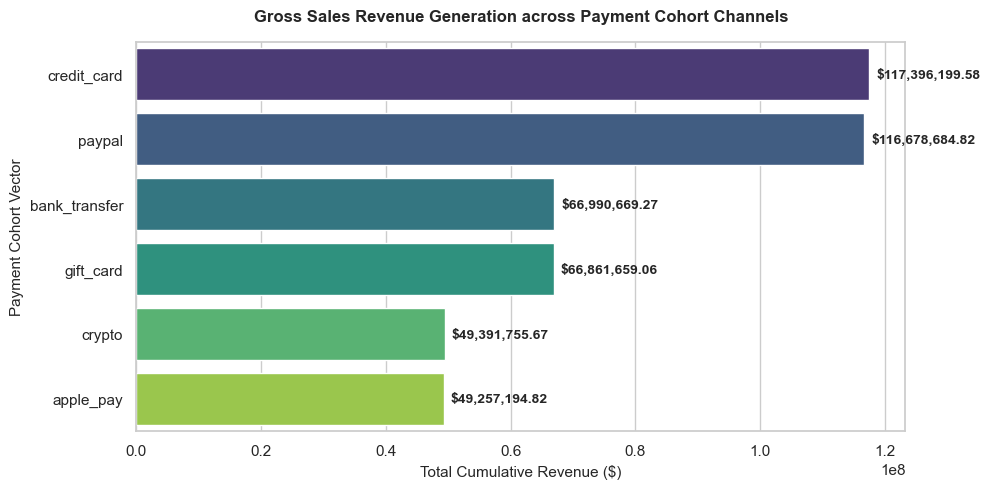

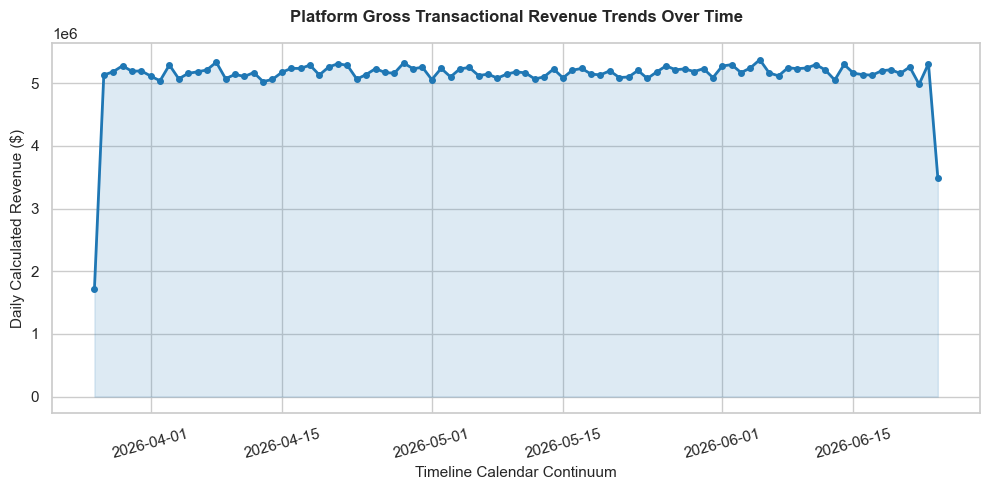

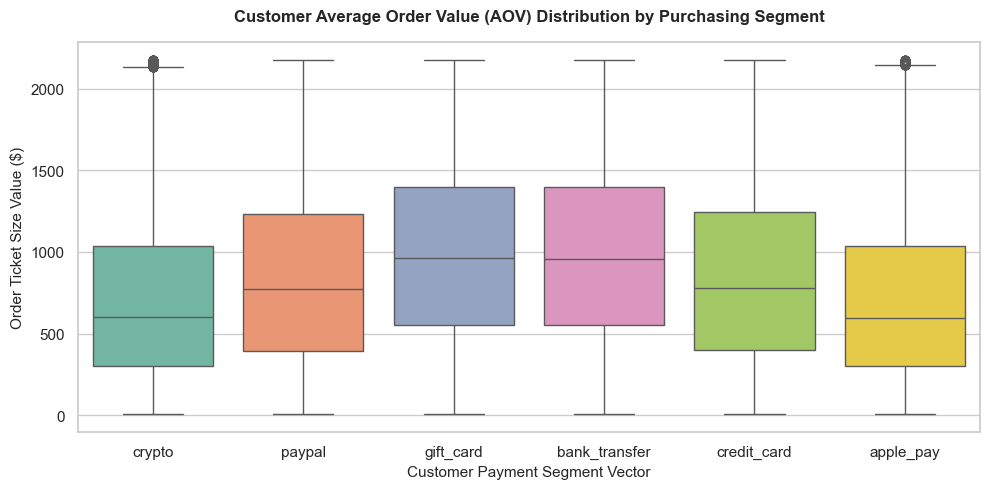

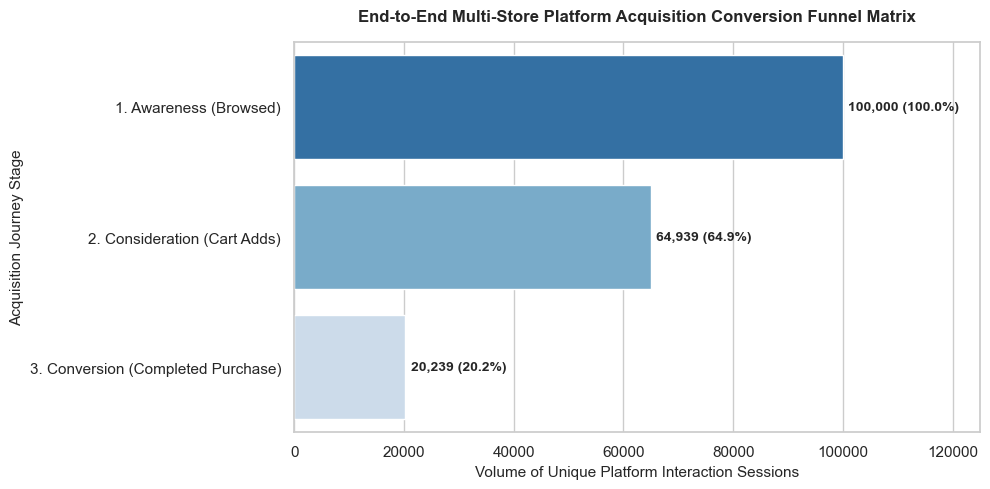


 SUCCESS! Enterprise Data Visualization Suite successfully generated.
All static plot images saved locally as high-resolution .png files.


In [7]:
import os
import json
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

DATA_FOLDER = r"C:\Users\user\Data"

print("Generating Part 4 Enterprise Visualization Suite...")

# Connect to our active local data layers
with open(os.path.join(DATA_FOLDER, "transactions.json"), "r") as f:
    df_tx = pd.DataFrame(json.load(f))
with open(os.path.join(DATA_FOLDER, "sessions_0.json"), "r") as f:
    df_sessions = pd.DataFrame(json.load(f))

db = duckdb.connect(database=':memory:')
df_tx_clean = db.query("SELECT * FROM df_tx WHERE status != 'cancelled'").df()

# Ensure we configure clean professional styling for all charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12, 'figure.titlesize': 14})

# =========================================================================
#  CHART 1: ACQUISITION CHANNEL COHORT PERFORMANCE (BAR CHART)
# =========================================================================
plt.figure(figsize=(10, 5))
df_cohort_plot = df_tx_clean.groupby('payment_method')['total'].sum().reset_index().sort_values(by='total', ascending=False)
ax1 = sns.barplot(x='total', y='payment_method', data=df_cohort_plot, palette='viridis', hue='payment_method', legend=False)

for p in ax1.patches:
    val = float(p.get_width())
    ax1.text(val + (df_cohort_plot['total'].max() * 0.01), p.get_y() + p.get_height()/2, f"${val:,.2f}", ha="left", va="center", fontweight='bold')

plt.title("Gross Sales Revenue Generation across Payment Cohort Channels", pad=15, fontweight='bold')
plt.xlabel("Total Cumulative Revenue ($)")
plt.ylabel("Payment Cohort Vector")
plt.tight_layout()
plt.savefig("chart_1_payment_revenue.png", dpi=300)
plt.show()

# =========================================================================
#  CHART 2: REVENUE DISTRIBUTION TREND LINES OVER TIME (LINE CHART)
# =========================================================================
plt.figure(figsize=(10, 5))
df_tx_clean['calendar_date'] = pd.to_datetime(df_tx_clean['timestamp']).dt.date
df_time_plot = df_tx_clean.groupby('calendar_date')['total'].sum().reset_index()

plt.plot(df_time_plot['calendar_date'], df_time_plot['total'], color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.fill_between(df_time_plot['calendar_date'], df_time_plot['total'], color='#1f77b4', alpha=0.15)

plt.title("Platform Gross Transactional Revenue Trends Over Time", pad=15, fontweight='bold')
plt.xlabel("Timeline Calendar Continuum")
plt.ylabel("Daily Calculated Revenue ($)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("chart_2_revenue_time.png", dpi=300)
plt.show()

# =========================================================================
#  CHART 3: CUSTOMER AVERAGE ORDER VALUE SPENDING SEGMENTS (BOX PLOT)
# =========================================================================
plt.figure(figsize=(10, 5))
# Outlier control: focus on standard order boundaries to clean the visualization box profiles
df_filtered_box = df_tx_clean[df_tx_clean['total'] <= df_tx_clean['total'].quantile(0.95)]

sns.boxplot(x='payment_method', y='total', data=df_filtered_box, palette='Set2', hue='payment_method', legend=False)
plt.title("Customer Average Order Value (AOV) Distribution by Purchasing Segment", pad=15, fontweight='bold')
plt.xlabel("Customer Payment Segment Vector")
plt.ylabel("Order Ticket Size Value ($)")
plt.tight_layout()
plt.savefig("chart_3_spending_distribution.png", dpi=300)
plt.show()

# =========================================================================
#  CHART 4: MULTI-STORE ACQUISITION CONVERSION FUNNEL (HORIZONTAL BAR CHART)
# =========================================================================
total_browsed = len(df_sessions)
df_sessions['has_cart'] = df_sessions['cart_contents'].apply(lambda x: len(x) > 0 if isinstance(x, dict) else False)
total_cart_adds = df_sessions['has_cart'].sum()
total_purchased = len(df_tx_clean[df_tx_clean['session_id'].isin(df_sessions['session_id'])])

funnel_df = pd.DataFrame({
    'Stage': ['1. Awareness (Browsed)', '2. Consideration (Cart Adds)', '3. Conversion (Completed Purchase)'],
    'Count': [total_browsed, total_cart_adds, total_purchased]
})

plt.figure(figsize=(10, 5))
ax4 = sns.barplot(x='Count', y='Stage', data=funnel_df, palette='Blues_r', hue='Stage', legend=False)

for p in ax4.patches:
    val = int(p.get_width())
    pct = (val / total_browsed) * 100
    ax4.text(val + (total_browsed * 0.01), p.get_y() + p.get_height()/2, f"{val:,} ({pct:.1f}%)", ha="left", va="center", fontweight='bold')

plt.title("End-to-End Multi-Store Platform Acquisition Conversion Funnel Matrix", pad=15, fontweight='bold')
plt.xlabel("Volume of Unique Platform Interaction Sessions")
plt.ylabel("Acquisition Journey Stage")
plt.xlim(0, total_browsed * 1.25)
plt.tight_layout()
plt.savefig("chart_4_conversion_funnel.png", dpi=300)
plt.show()

print("\n SUCCESS! Enterprise Data Visualization Suite successfully generated.")
print("All static plot images saved locally as high-resolution .png files.")
